In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Online_retail.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12:50,4.15,12680.0,France


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (406829, 8)


In [10]:
df['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
False    397924
True       8905
Name: count, dtype: int64

In [11]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [12]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [13]:
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


In [15]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [16]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [17]:
df['TotalAmount'].describe()

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

In [18]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [19]:
customer_summary = df.groupby('CustomerID').agg(
    Total_Spending=('TotalAmount', 'sum'),
    Purchase_Frequency=('InvoiceNo', 'nunique'),
    Average_Purchase_Value=('TotalAmount', 'mean')
).reset_index()

customer_summary.head()

,CustomerID,Total_Spending,Purchase_Frequency,Average_Purchase_Value
0,12346.0,77183.60,1,77183.600000
1,12347.0,4310.00,7,23.681319
2,12348.0,1797.24,4,57.975484
3,12349.0,1757.55,1,24.076027
4,12350.0,334.40,1,19.670588


In [20]:
print("Average Purchase Value:",
      customer_summary['Average_Purchase_Value'].mean())

print("Average Purchase Frequency:",
      customer_summary['Purchase_Frequency'].mean())

print("Average Customer Lifetime Value:",
      customer_summary['Total_Spending'].mean())

Average Purchase Value: 68.35050559551645
Average Purchase Frequency: 4.272014753342554
Average Customer Lifetime Value: 2054.2664601198708


In [21]:
customer_summary[['Total_Spending',
                  'Purchase_Frequency',
                  'Average_Purchase_Value']].describe()

,Total_Spending,Purchase_Frequency,Average_Purchase_Value
count,4338.000000,4338.000000,4338.000000
mean,2054.266460,4.272015,68.350506
std,8989.230441,7.697998,1467.918896
min,3.750000,1.000000,2.101286
25%,307.415000,1.000000,12.365367
50%,674.485000,2.000000,17.723119
75%,1661.740000,5.000000,24.858417
max,280206.020000,209.000000,77183.600000


In [22]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    dayfirst=True
)

In [23]:
print(df['InvoiceDate'].dtype)
df[['InvoiceDate']].head()

datetime64[ns]


,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [24]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [25]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

In [26]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [27]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [28]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

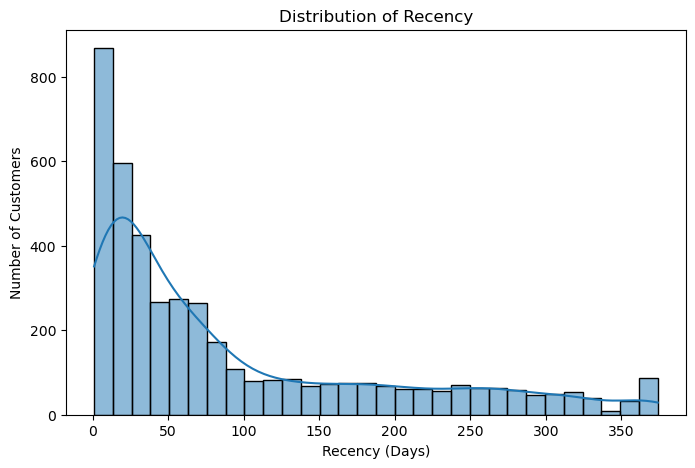

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.show()

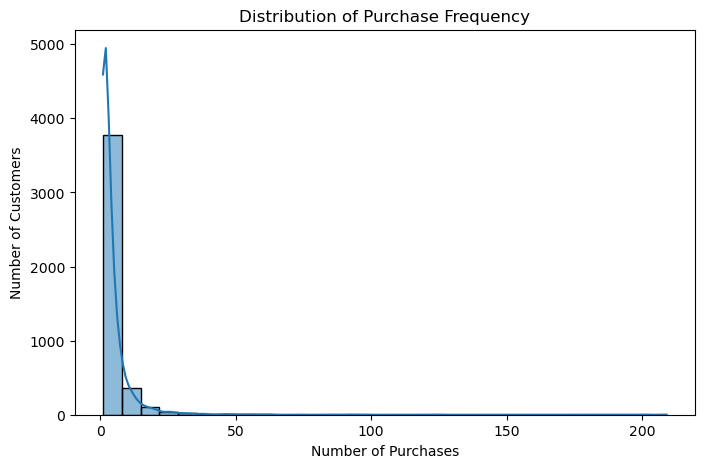

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Distribution of Purchase Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

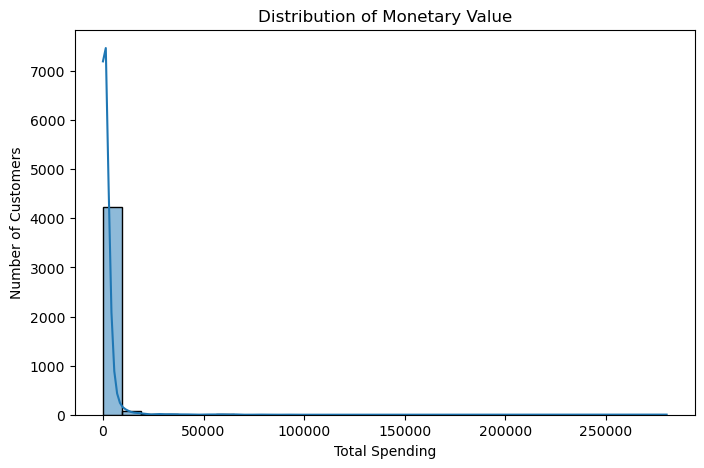

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Distribution of Monetary Value')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

In [32]:
### Observation

The RFM features show different customer purchasing behaviours. 
    Recency represents how recently customers purchased, while Frequency represents the number of purchases. 
    Monetary represents the total amount spent by each customer. 
    The distributions also show that some customers have much higher purchase frequency and spending than others, 
which makes standardisation important before applying K-Means clustering.

SyntaxError: invalid syntax (2070931201.py, line 3)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [ ]:
rfm_features.head()

In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [ ]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled.head()

In [ ]:
rfm_scaled.describe()

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.show()

In [ ]:
### Elbow Method Observation

The Elbow Method was used to determine the optimal number of customer segments. 
    The inertia decreases as the number of clusters increases, but after the elbow point the improvement becomes smaller. 
    Therefore, the K value at the elbow point is selected as the optimal number of clusters for K-Means.

In [ ]:
optimal_k = 4

In [ ]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm.head()

In [ ]:
rfm['Cluster'].value_counts().sort_index()

In [ ]:
### K-Means Clustering

K-Means clustering was applied to the standardized Recency, Frequency, and Monetary features. 
    Customers were divided into the optimal number of clusters identified using the Elbow Method.
    Each customer has now been assigned to a cluster representing a group with similar purchasing behaviour.

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.legend(title='Cluster')
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')
plt.legend(title='Cluster')
plt.show()

In [ ]:
### Cluster Visualization Observations

The scatter plots show that customers are distributed into distinct groups based on their purchasing behaviour. 
    The Recency vs Frequency plot highlights differences in customer activity and purchase frequency. 
        The Frequency vs Monetary plot shows differences in purchasing frequency and total spending.
    The separation between clusters indicates that K-Means has identified groups with different customer behaviours.

In [ ]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

cluster_profile

In [ ]:
cluster_profile.round(2)

In [ ]:
## Customer Segment Profiles

- Cluster 0 – Regular Customers: These customers show moderate purchasing activity, frequency, and spending.
- Cluster 1 – At-Risk / Inactive Customers: These customers have not purchased recently and show low purchase frequency and spending.
- Cluster 2 – VIP / High-Value Customers: These customers purchase very frequently, have recent transactions, and generate exceptionally high revenue.
- Cluster 3 – Loyal Customers: These customers purchase relatively frequently, have recent transactions, and contribute high spending.

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x='Cluster'
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
### Observation

Cluster 0 contains the largest number of customers, followed by Cluster 1. 
    Cluster 3 contains a smaller group of loyal customers, while Cluster 2 has only a small number of VIP customers. 
    Although Cluster 2 is small, its customers have exceptionally high purchasing frequency and monetary value.

In [ ]:
## Marketing Recommendations

### Cluster 0 – Regular Customers
These customers have moderate purchasing activity and spending. 
Marketing action: Provide personalized product recommendations, targeted discounts, and loyalty rewards to increase their purchase frequency and spending.

### Cluster 1 – At-Risk / Inactive Customers
These customers have high recency, meaning they have not purchased recently, along with low frequency and spending.
Marketing action: Use re-engagement campaigns, special discounts, reminder emails, and limited-time offers to encourage them to return.

### Cluster 2 – VIP / High-Value Customers
These customers purchase very frequently, purchased recently, and generate exceptionally high monetary value.
Marketing action: Provide VIP treatment, exclusive offers, early access to new products, premium rewards, and personalized customer service to retain them.

### Cluster 3 – Loyal Customers
These customers purchase frequently, have recent purchases, and contribute significant revenue.
Marketing action: Strengthen loyalty through membership programs, reward points, cross-selling, upselling, and personalized recommendations.

In [ ]:
# Conclusion

The K-Means clustering analysis successfully segmented customers based on Recency, Frequency, and Monetary (RFM) behaviour. Four distinct customer segments were identified.

### Key Findings

1. Cluster 0 – Regular Customers:
   This is the largest customer segment, with moderate recency, purchase frequency, and spending.

2. Cluster 1 – At-Risk / Inactive Customers:
   These customers have not purchased recently and have relatively low purchase frequency and spending.

3. Cluster 2 – VIP / High-Value Customers:
   Although this segment contains only a small number of customers, they have extremely high purchase frequency and monetary value, making them highly valuable to the business.

4. Cluster 3 – Loyal Customers:
   These customers purchase frequently, have recent transactions, and generate significant revenue.

### Actionable Business Recommendations

1. Retain VIP customers:
   Provide exclusive rewards, early access to products, personalized offers, and premium customer service to prevent high-value customers from leaving.

2. Reactivate at-risk customers:
   Launch targeted re-engagement campaigns with personalized discounts, reminder emails, and limited-time offers.

3. Increase regular customer value:
   Use product recommendations, cross-selling, upselling, and loyalty rewards to increase purchase frequency and spending.

4. Strengthen customer loyalty:
   Introduce membership programs and reward points for loyal customers to encourage repeat purchases and long-term retention.

Overall, RFM-based K-Means clustering provides a practical way for the business to understand different customer behaviours and develop targeted marketing strategies for each customer segment.